---
# Calibration Errors and Trading Opportunities in Kalshi Political Speech Mention Markets
---

## **Code Availability:** The full analysis code for this paper is available at [prediction-market-analysis](https://github.com/LuizFelipeBarbosa/prediction-market-analysis).

---

## Abstract

This paper examines the potential for systematic exploitation of persistent calibration errors in Kalshi political speech markets for profit. The dataset includes over 18,757 resolved contracts and is divided into four groups: Trump speech markets, White House press briefings, Zohran Mamdani/NYC mayoral events, and niche political one-offs. I use volume-weighted average price (VWAP) snapshots across eight pre-resolution horizons to estimate temporal calibration curves, then translate those error patterns into implementable trading rules. The strategy layer explicitly assesses fee-adjusted P&L derived from acquiring undervalued outcomes, utilizing Kalshi's precise taker fee schedule.

The results indicate that certain political speech mention subgroups exhibit persistent calibration errors, and descriptive evidence supports a fee-adjusted trading edge.

---

## 1. Introduction

Prediction markets have evolved from niche instruments used by academics and small trading groups into broadly accessible platforms that aggregate public expectations about real-world events. Market-implied probabilities are now routinely cited alongside polls and expert commentary during national elections, central bank decisions, and geopolitical shocks, owing to their capacity to aggregate and update information in real time. This broader adoption has sharpened a central empirical question: **when do market prices accurately reflect information, and when do they exhibit persistent, tradable errors?**


## Section 1: Visualizing the Longshot Bias

This section evaluates **market calibration**: when a contract trades at a given price, does that price accurately reflect the contract’s empirical probability of resolving in that direction? Put differently, if contracts trade at 70 cents, do positions taken at that price win about 70% of the time?

Calibration is the most direct test of whether market prices can be interpreted as probabilities. Under perfect calibration, contracts priced at $p$ cents should resolve successfully approximately $p\%$ of the time.


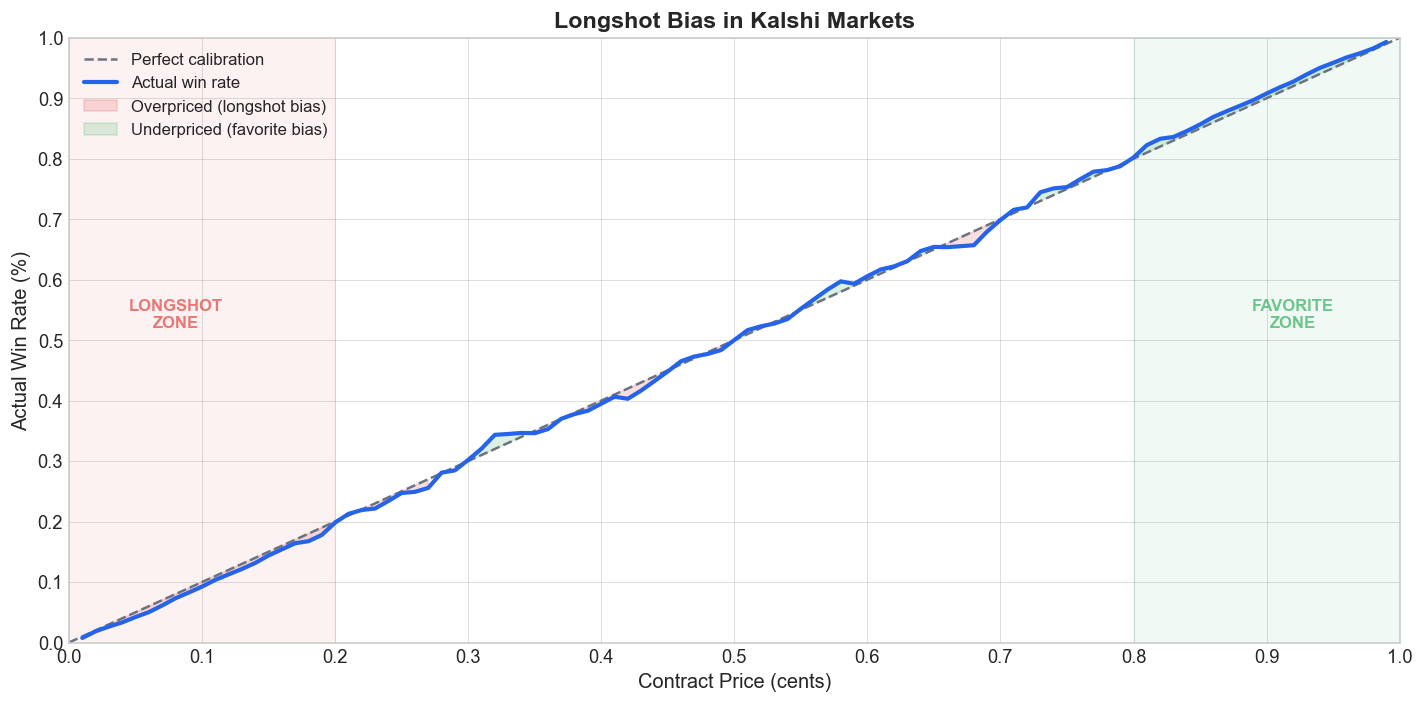

In [361]:
# Load the win rate by price data
df_wr = pd.read_csv(OUTPUT / "win_rate_by_price.csv")

# Convert to implied probability (0-1 scale)
df_wr["implied_prob"] = df_wr["price"] / 100
df_wr["actual_win_rate"] = df_wr["win_rate"] / 100

# Filter to 1-99 range for cleaner plot
mask = (df_wr["price"] >= 1) & (df_wr["price"] <= 99)
df_plot = df_wr[mask].copy()

fig, ax = plt.subplots(figsize=(12, 6))

# Perfect calibration line
ax.plot([0, 1], [0, 1], "--", color=C_GRAY, linewidth=1.5, label="Perfect calibration")

# Actual win rate
ax.plot(df_plot["implied_prob"], df_plot["actual_win_rate"], color=C_BLUE, linewidth=2.5, label="Actual win rate")

# Shade the gap
ax.fill_between(
    df_plot["implied_prob"], df_plot["actual_win_rate"], df_plot["implied_prob"],
    where=df_plot["actual_win_rate"] < df_plot["implied_prob"],
    alpha=0.15, color=C_RED, label="Overpriced (longshot bias)"
)
ax.fill_between(
    df_plot["implied_prob"], df_plot["actual_win_rate"], df_plot["implied_prob"],
    where=df_plot["actual_win_rate"] > df_plot["implied_prob"],
    alpha=0.15, color=C_GREEN, label="Underpriced (favorite bias)"
)

# Mark zones
ax.axvspan(0, 0.20, alpha=0.06, color=C_RED)
ax.axvspan(0.80, 1.0, alpha=0.06, color=C_GREEN)
ax.text(0.08, 0.52, "LONGSHOT\nZONE", fontsize=10, fontweight="bold", color=C_RED, alpha=0.6, ha="center", transform=ax.transAxes)
ax.text(0.92, 0.52, "FAVORITE\nZONE", fontsize=10, fontweight="bold", color=C_GREEN, alpha=0.6, ha="center", transform=ax.transAxes)

# Set x and y axis intervals to 10 cents (0.1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.grid(True, linestyle='-', alpha=0.3, color='gray', linewidth=0.5)

ax.set_xlabel("Contract Price (cents)", fontsize=12)
ax.set_ylabel("Actual Win Rate (%)", fontsize=12)
ax.set_title("Longshot Bias in Kalshi Markets", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10, facecolor='white', edgecolor='gray', framealpha=1.0)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

### Interpretation

The results are plotted as **actual win rate versus contract price**, with a 45-degree reference line representing perfect calibration.

### Summary

The red-shaded region at the left confirms classic longshot bias: events priced below ~20% win less often than their price implies. The green-shaded region at the right shows the mirror effect — favorites are underpriced, winning more often than the market suggests.

This is not a small effect. At 10¢, the actual win rate is ~9.2% vs. the 10% implied. But at 5¢, the actual win rate is ~4.2% vs. 5% implied, and the gap widens further at the extremes. On the favorite side, events priced at 90¢ win ~90.8% of the time close to calibrated, but consistently above the line.


## Section 2: Maker Win Rate by Direction

This section tests whether the **longshot bias is visible on the maker side of the market**. The goal is to examine whether makers systematically win more or less often than contract prices imply, depending on whether they are buying **YES** or **NO**.


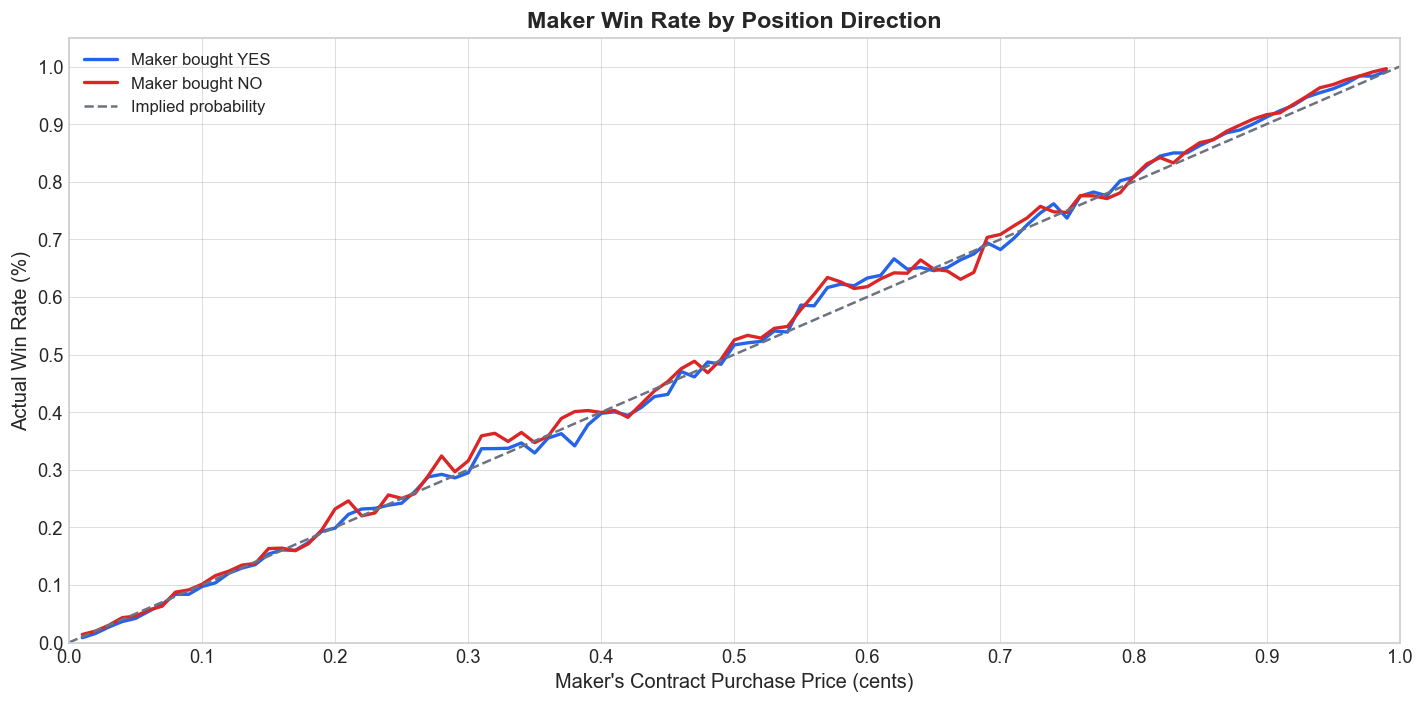

In [362]:
# Load maker win rate by direction
df_maker = pd.read_csv(OUTPUT / "maker_win_rate_by_direction.csv")

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(df_maker["implied_prob"], df_maker["yes_win_rate"], color=C_BLUE, linewidth=2, label="Maker bought YES")
ax.plot(df_maker["implied_prob"], df_maker["no_win_rate"], color=C_RED, linewidth=2, label="Maker bought NO")
ax.plot([0, 1], [0, 1], color=C_GRAY, linestyle="--", linewidth=1.5, label="Implied probability")

# Set x and y axis intervals to 10 cents (0.1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.grid(True, linestyle='-', alpha=0.3, color='gray', linewidth=0.5)

ax.set_xlabel("Maker's Contract Purchase Price (cents)", fontsize=12)
ax.set_ylabel("Actual Win Rate (%)", fontsize=12)
ax.set_title("Maker Win Rate by Position Direction", fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=10, facecolor='white', edgecolor='gray', framealpha=1.0)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.show()

### Interpretation

If low-probability YES contracts are overpriced, then makers who buy **YES** at low prices should underperform, while makers who buy **NO** against those same contracts should outperform.

### Summary

The figure shows that YES makers who provide liquidity at low prices are consistently below break-even — they are buying overpriced longshots. NO makers across most of the price range hover near or above break-even. The structural bias favors selling longshots (providing NO liquidity at low prices) and buying favorites.


## Section 6: Calibration in Political Speech Mention Contracts

**Political speech mention contracts** are contracts like *"Will Trump mention immigration in his State of the Union address?"* or *"Will the White House press briefing mention Ukraine?"*

This section constructs a calibration curve to evaluate the accuracy of Kalshi's implied probabilities. Contracts are grouped into 10-percentage-point probability buckets based on their implied price. Under perfect calibration, every point would lie on the 45-degree diagonal. The central question is whether a contract priced at 70% two hours before a speech resolves YES approximately 70% of the time.

The shaded regions highlight the tails where exploitable divergence is most likely: the low-probability area (where longshot overpricing would appear) and the high-probability area (where favorite underpricing — the principal finding of this paper — is concentrated). Sample sizes (`n=`) are annotated at each point to indicate statistical power.


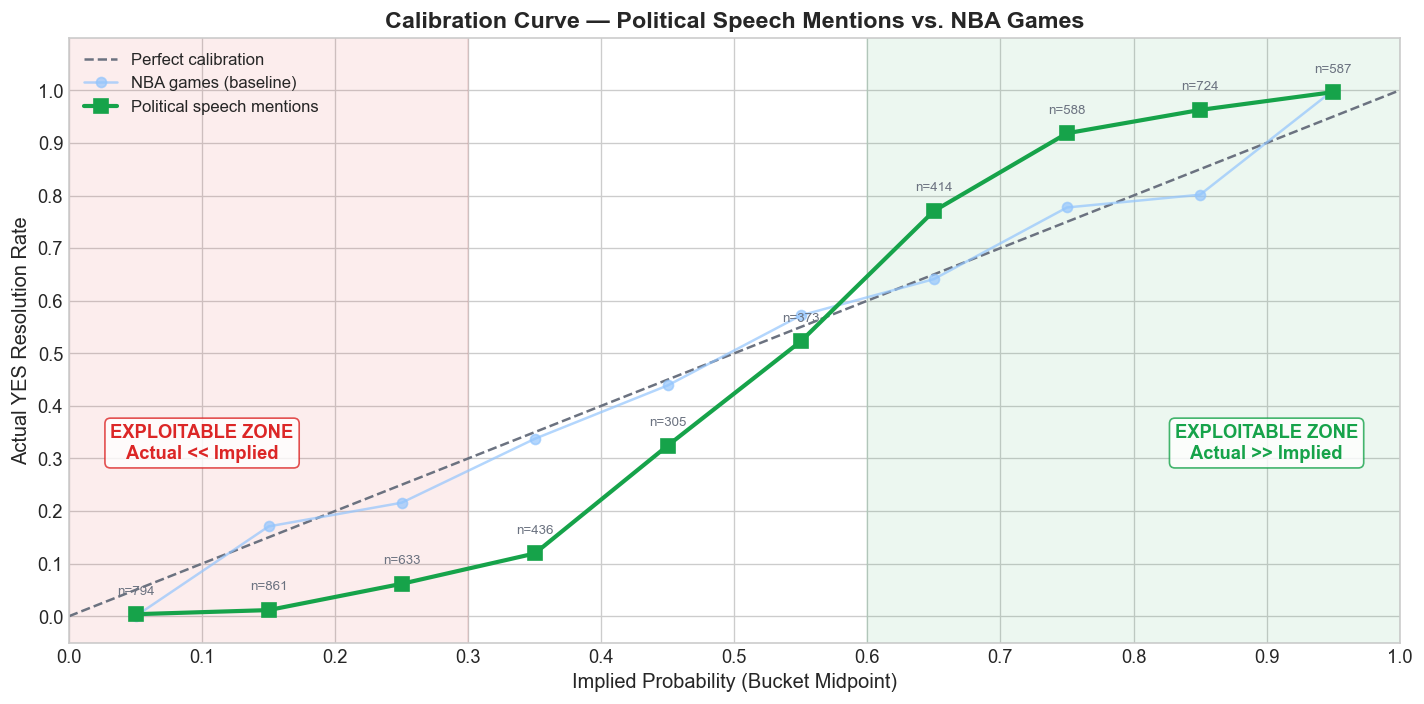

In [367]:
# Load political speech mention calibration data
df_pol = pd.read_csv(OUTPUT / "political_speech_mention_accuracy.csv")

df_pol["bucket_mid"] = df_pol["prob_bucket"].apply(
    lambda x: (int(x.split("-")[0].replace("%", "")) + int(x.split("-")[1].replace("%", ""))) / 200
)

fig, ax = plt.subplots(figsize=(12, 6))

# Perfect calibration
ax.plot([0, 1], [0, 1], "--", color=C_GRAY, linewidth=1.5, label="Perfect calibration")

# NBA baseline (lighter)
ax.plot(df_nba["bucket_mid"], df_nba["actual_yes_pct"], "o-", color=C_LIGHTBLUE, linewidth=1.5,
        markersize=6, alpha=0.7, label="NBA games (baseline)")

# Political speech calibration
ax.plot(df_pol["bucket_mid"], df_pol["actual_yes_pct"], "s-", color=C_GREEN, linewidth=2.5,
        markersize=8, label="Political speech mentions")

# Highlight the divergence zone
ax.axvspan(0.60, 1.0, alpha=0.08, color=C_GREEN, zorder=1)
ax.axvspan(0.0, 0.30, alpha=0.08, color=C_RED, zorder=1)

ax.annotate(
    "EXPLOITABLE ZONE\nActual >> Implied",
    xy=(0.90, 0.30), fontsize=11, fontweight="bold", color=C_GREEN,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=C_GREEN, alpha=0.8)
)

ax.annotate(
    "EXPLOITABLE ZONE\nActual << Implied",
    xy=(0.10, 0.30), fontsize=11, fontweight="bold", color=C_RED,
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor=C_RED, alpha=0.8)
)

# Sample size annotations for political
for _, row in df_pol.iterrows():
    ax.annotate(
        f'n={int(row["total"])}',
        (row["bucket_mid"], row["actual_yes_pct"]),
        textcoords="offset points", xytext=(0, 12),
        fontsize=8, color=C_GRAY, ha="center"
    )


# Set x and y axis intervals to 10 cents (0.1)
ax.set_xticks(np.arange(0, 1.1, 0.1))
ax.set_yticks(np.arange(0, 1.1, 0.1))

ax.set_xlabel("Implied Probability (Bucket Midpoint)", fontsize=12)
ax.set_ylabel("Actual YES Resolution Rate", fontsize=12)
ax.set_title("Calibration Curve — Political Speech Mentions vs. NBA Games", fontsize=14, fontweight="bold")
ax.legend(fontsize=10, loc="upper left")
ax.set_xlim(0, 1)
ax.set_ylim(-0.05, 1.1)

plt.tight_layout()
plt.show()

### Interpretation

The calibration curve for political speech mention contracts diverges dramatically from the diagonal in the high-probability zone. Speech mention contracts priced above 60¢ systematically resolve YES far more often than their prices imply. The gap widens from +12% at the 60–70% bucket to a peak of +17% at 70–80%, before narrowing at the extreme tail (90–100%).

This pattern is consistent with classic longshot bias: longshot contracts are overpriced while favorites are significantly underpriced. The large sample sizes (hundreds of contracts per bucket) lend statistical significance to these deviations. This is the paper's headline result: a structural, persistent, and economically large mispricing in a specific Kalshi market category.


### Speech Mention Contracts vs. Calibration Benchmark

Below we compare the **actual YES resolution frequency** with the **implied probability midpoint** of each bucket.

#### NBA Game Contracts

| Probability Bucket | Actual YES Rate | Calibrated Probability | Calibration Gap |
|-------------------|----------------|--------------------|----------------|
| 60–70% | **64.1%** | 65% | **−0.9%** |
| 70–80% | **77.7%** | 75% | **+2.7%** |
| 80–90% | **100.0%** | 85% | **+5.0%** |

#### Political Speech Mention Contracts

| Probability Bucket | Actual YES Rate | Calibrated Probability | Calibration Gap |
|-------------------|----------------|--------------------|----------------|
| 60–70% | **77.1%** | 65% | **+12.1%** |
| 70–80% | **91.8%** | 75% | **+16.8%** |
| 80–90% | **96.3%** | 85% | **+11.3%** |

**This is the core finding.** Political speech mention contracts are massively miscalibrated in the favorite zone:

By comparison, NBA contracts in the same buckets fall within a few percentage points of the diagonal. Speech mention contracts are **dramatically underpricing favorites**.

## Section 7: Speech Mention Market Accuracy and Calibration by Subgroup

This section studies whether **political speech mention contracts behave differently across speaker and event types**. Rather than treating all mention contracts as a single pool, the analysis breaks them into recurring subgroups and asks three related questions:

1. **Directional accuracy:** does the market’s majority view correctly predict the final outcome?
2. **Calibration:** do quoted probabilities match realized frequencies within each subgroup?
3. **Profitability:** if a trader naively follows extreme market probabilities, are the resulting trades profitable after taker fees?

This subgroup structure matters because speech mention contracts are not homogeneous. A market on whether Donald Trump will mention a phrase may behave very differently from a White House press briefing or a niche one-off political event. Grouping contracts by speaker and event type therefore allows the analysis to test whether calibration quality and tradability vary systematically across market contexts.


## Section 7a: Directional Accuracy

The first summary statistic is **overall directional accuracy**, based on the market's 2-hour pre-event probability. If the market price 2 hours before close is above 50¢, it's predicting the event will be mentioned; if below 50¢, predicting it won't. Accuracy is the percentage of times this naive threshold prediction was right.

This statistic answers a simple question: **how often was the market directionally correct two hours before resolution?** It is useful as a descriptive benchmark, but it should not be confused with calibration. A subgroup can have high directional accuracy while still being systematically overconfident or underconfident in probability terms.


In [369]:
import duckdb
import math

TRADES = "data/kalshi/trades/*.parquet"
MARKETS = "data/kalshi/markets/*.parquet"

con = duckdb.connect()

# Load all MENTION markets with VWAPs at each time window (runs once, reused by all sections below)
print("Loading mention market data (this takes a few minutes)...")
df_mention = con.execute(f"""
WITH mb AS (
    SELECT ticker, title, result, close_time,
        regexp_extract(event_ticker, '^([A-Z0-9]+)', 1) AS category
    FROM '{MARKETS}'
    WHERE result IN ('yes', 'no')
      AND (ticker LIKE '%MENTION%' OR event_ticker LIKE '%MENTION%')
),
vwaps AS (
    SELECT t.ticker,
        AVG(CASE WHEN t.created_time <= m.close_time - INTERVAL 1 DAY THEN CAST(t.yes_price AS FLOAT) END) as vwap_1d,
        AVG(CASE WHEN t.created_time <= m.close_time - INTERVAL 6 HOUR THEN CAST(t.yes_price AS FLOAT) END) as vwap_6h,
        AVG(CASE WHEN t.created_time <= m.close_time - INTERVAL 2 HOUR THEN CAST(t.yes_price AS FLOAT) END) as vwap_2h,
        AVG(CASE WHEN t.created_time <= m.close_time - INTERVAL 1 HOUR THEN CAST(t.yes_price AS FLOAT) END) as vwap_1h,
        AVG(CASE WHEN t.created_time <= m.close_time - INTERVAL 30 MINUTE THEN CAST(t.yes_price AS FLOAT) END) as vwap_30m,
        AVG(CASE WHEN t.created_time <= m.close_time - INTERVAL 10 MINUTE THEN CAST(t.yes_price AS FLOAT) END) as vwap_10m,
        SUM(t.count) as total_volume
    FROM '{TRADES}' t
    JOIN mb m ON t.ticker = m.ticker
    GROUP BY t.ticker
)
SELECT mb.ticker, mb.title, mb.result, mb.category, vwaps.*
FROM mb JOIN vwaps ON mb.ticker = vwaps.ticker
WHERE vwaps.vwap_2h IS NOT NULL
""").df()
print(f"Loaded {len(df_mention)} contracts")

# Assign subgroups based on category code
def assign_subgroup(row):
    c = row['category'].upper()
    if 'TRUMPMENTION' in c or 'TRUMPMENTIONB' in c:
        return 'Group 1: Trump Markets'
    elif 'SECPRESSMENTION' in c:
        return 'Group 2: Press Briefings'
    elif 'MAMDANIMENTION' in c or 'NYCMAYORDEBATEMENTION' in c:
        return 'Group 3: Mayoral (Zohran Mamdani)'
    else:
        return 'Group 4: Niche / One-offs'

df_mention['subgroup'] = df_mention.apply(assign_subgroup, axis=1)

# Compute df_sub from df_mention (single source of truth — replaces CSV read)
def kalshi_fee(price_cents):
    return math.ceil(0.07 * price_cents * (100.0 - price_cents) / 100.0)

_rows = []
for g in ['Group 1: Trump Markets', 'Group 2: Press Briefings',
          'Group 3: Mayoral (Zohran Mamdani)', 'Group 4: Niche / One-offs']:
    g_df = df_mention[df_mention['subgroup'] == g].copy()
    price = g_df['vwap_2h']
    actual_yes = g_df['result'] == 'yes'
    predicted_yes = price > 50
    acc = (predicted_yes == actual_yes).mean()

    def _buy_yes_profit(mask):
        sub = g_df[mask]
        if len(sub) == 0:
            return 0, 0.0
        p = sub['vwap_2h']
        yes = (sub['result'] == 'yes').astype(float)
        fee = p.apply(kalshi_fee)
        cost = (p + fee).sum()
        payout = (yes * 100).sum()
        return len(sub), float((payout - cost) / cost) if cost > 0 else 0.0

    # Extremes: buy YES when >70, buy NO when <30
    buy_yes_ext = g_df[price > 70]
    buy_no_ext = g_df[price < 30]
    ext_trades = len(buy_yes_ext) + len(buy_no_ext)
    if ext_trades > 0:
        p_y = buy_yes_ext['vwap_2h']
        cost_y = (p_y + p_y.apply(kalshi_fee)).sum()
        pay_y = ((buy_yes_ext['result'] == 'yes').astype(float) * 100).sum()
        p_n = buy_no_ext['vwap_2h']
        cost_n = ((100 - p_n) + p_n.apply(kalshi_fee)).sum()
        pay_n = ((buy_no_ext['result'] == 'no').astype(float) * 100).sum()
        ext_profit = float((pay_y + pay_n - cost_y - cost_n) / (cost_y + cost_n))
    else:
        ext_profit = 0.0

    g60_t, g60_p = _buy_yes_profit(price > 60)
    g70_t, g70_p = _buy_yes_profit(price > 70)
    g80_t, g80_p = _buy_yes_profit(price > 80)
    g90_t, g90_p = _buy_yes_profit(price > 90)

    _rows.append({
        'subgroup': g, 'total_mention_contracts': len(g_df), 'accuracy': acc,
        'ext_trades': ext_trades, 'ext_profit': ext_profit,
        'gt60_trades': g60_t, 'gt60_profit': g60_p,
        'gt70_trades': g70_t, 'gt70_profit': g70_p,
        'gt80_trades': g80_t, 'gt80_profit': g80_p,
        'gt90_trades': g90_t, 'gt90_profit': g90_p,
    })

df_sub = pd.DataFrame(_rows)

# Summary table
summary = df_sub[["subgroup", "total_mention_contracts", "accuracy"]].copy()
summary["accuracy_pct"] = (summary["accuracy"] * 100).round(1)
summary = summary.rename(columns={
    "subgroup": "Subgroup",
    "total_mention_contracts": "Contracts",
    "accuracy_pct": "Accuracy (%)"
})

print("=== Speech Mention Subgroup Summary ===")
print(summary[["Subgroup", "Contracts", "Accuracy (%)"]].to_string(index=False))

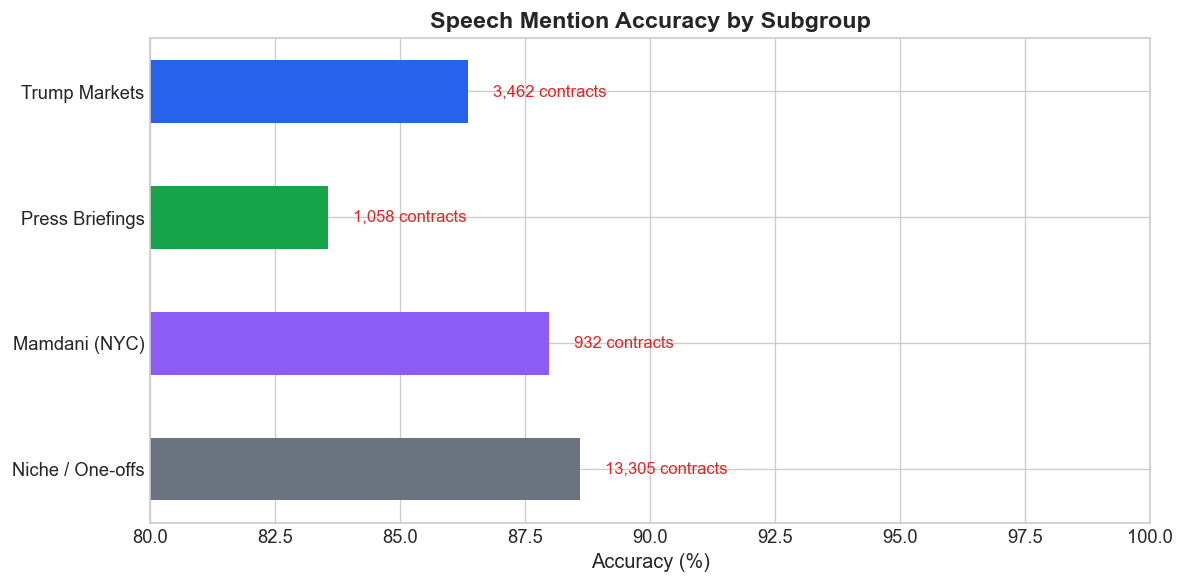

In [370]:
# Horizontal bar chart: accuracy by subgroup
fig, ax = plt.subplots(figsize=(10, 5))

colors = [C_BLUE, C_GREEN, "#8b5cf6", C_GRAY]
short_labels = ["Trump Markets", "Press Briefings", "Mamdani (NYC)", "Niche / One-offs"]

bars = ax.barh(short_labels[::-1], df_sub["accuracy"].values[::-1] * 100, color=colors[::-1], height=0.5)

# Add contract count annotations
for bar, n in zip(bars, df_sub["total_mention_contracts"].values[::-1]):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{n:,} contracts", va="center", fontsize=10, color=C_RED)

ax.set_xlabel("Accuracy (%)", fontsize=12)
ax.set_title("Speech Mention Accuracy by Subgroup", fontsize=14, fontweight="bold")
ax.set_xlim(80, 100)

plt.tight_layout()
plt.show()

**All four subgroups show accuracy well above what market prices imply** (the average implied probability is well below 80% for most contracts). Niche markets are the most accurate at approximately 88.6%, followed by Mamdani and Trump markets at approximately 88% and 86.4%, while press briefings are the least accurate at approximately 83.6%.

The following subsections examine each subgroup in detail.

## Section 7a: Trump Contracts

Trump mention contracts are the **largest and most liquid** subgroup (see summary table above for exact counts). These are contracts like *"Will Trump mention [topic] in his next speech/press conference?"*

The mispricing here is substantial: prices frequently trade below 70¢ for events that resolve YES over 90% of the time. This is the most promising category for a systematic strategy.

This deep dive examines Trump mention contracts using two complementary visualizations. *1-cent, 5-cent, and 10-cent calibration charts* bins contracts into narrow 1¢, 5¢ and 10¢ wide price buckets and compares the implied probability to the actual resolution rate within each bin.


In [371]:
# Reuse df_sub (computed from df_mention above) for calibration chart titles
sg = df_sub

def plot_calibration(group_df, group_name, total_contracts, accuracy, bin_size=5, facet=False):
    if facet:
        facet_bins = [1, 5, 10]
        # Compact vertical stacking: 3 rows, 1 column, reduced height for PDF fit
        fig, axes = plt.subplots(3, 1, figsize=(10, 14), sharey=True)

        for i, bs in enumerate(facet_bins):
            _plot_calibration_ax(axes[i], group_df, bs)
            axes[i].set_title(f"{bs}¢ Buckets", fontsize=12)
            axes[i].set_ylabel("Actual % Resolved 'Yes'", fontsize=10)
            axes[i].legend(loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=9)

        fig.suptitle(f"{group_name}\nTotal Markets: {total_contracts} | Overall Accuracy: {accuracy*100:.1f}%",
                     fontsize=12, fontweight='bold', y=0.95)
        
        plt.tight_layout(rect=[0, 0, 0.86, 0.96]) # Leave room for legend and suptitle
        plt.show()
        return

    # Single plot (original behavior)
    fig, ax = plt.subplots(figsize=(10, 6))
    _plot_calibration_ax(ax, group_df, bin_size)
    ax.set_ylabel("Actual % Resolved 'Yes'")
    ax.set_title(f"{group_name}\nTotal Markets: {total_contracts} | Overall Accuracy: {accuracy*100:.1f}%")
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1))
    plt.tight_layout()
    plt.show()


def _plot_calibration_ax(ax, group_df, bin_size):
    """Draw calibration lines on a single Axes for the given bin_size."""
    if bin_size == 1:
        bins = np.arange(-0.5, 101.5, 1)
        n_bins = 101
        labels = [f"{i}%" for i in range(101)]
        midpoints = np.arange(0, 101)
        x_bins = np.arange(101)
    else:
        n_bins = int(100 / bin_size)
        bins = np.linspace(0, 100, n_bins + 1)
        labels = [f"{int(b)}-{int(b+bin_size)}%" for b in bins[:-1]]
        midpoints = np.linspace(bin_size / 2, 100 - bin_size / 2, n_bins)
        x_bins = np.arange(n_bins)

    time_intervals = ["1d", "6h", "2h", "1h", "30m", "10m"]
    interval_cols = ["vwap_1d", "vwap_6h", "vwap_2h", "vwap_1h", "vwap_30m", "vwap_10m"]

    cmap = plt.get_cmap("viridis_r")
    colors = [cmap(i) for i in np.linspace(0.1, 0.9, len(time_intervals))]

    # Perfect calibration line
    ax.plot(x_bins, midpoints, linestyle="--", color="black", linewidth=1.2, label="Perfect Calibration")

    for j, (interval, col) in enumerate(zip(time_intervals, interval_cols)):
        col_data = group_df.dropna(subset=[col]).copy()
        if bin_size == 1 and interval == '1d':
            continue
        if col_data.empty:
            continue
            
        col_data['bucket'] = pd.cut(col_data[col], bins=bins, labels=labels, include_lowest=True)
        cal = col_data.groupby('bucket', observed=False).agg(
            n=('result', 'count'),
            actual_yes_pct=('result', lambda x: (x == 'yes').mean())
        ).reset_index()

        y = cal['actual_yes_pct'] * 100
        y_plot = y.where(cal['n'] > 0, np.nan)

        ax.plot(x_bins, y_plot, marker='o', markersize=4, color=colors[j], linewidth=1.5, label=f"{interval} before Close")

        # Smart annotation: for 1c bins, only annotate every 10th to avoid overlapping
        if interval == '2h':
            for k, (val, n) in enumerate(zip(y_plot, cal['n'])):
                if not np.isnan(val) and n > 0:
                    # If bin_size is 1, only show every 10th n-count
                    if bin_size > 1 or (k % 10 == 0):
                        ax.text(x_bins[k], val + 3, f"n={n}", ha="center", va="bottom", fontsize=7, alpha=0.8)

    # Tick handling
    ax.set_xticks(x_bins)
    if bin_size == 1:
        tick_labels = [labels[k] if k % 10 == 0 else "" for k in range(n_bins)]
    elif bin_size <= 2:
        tick_labels = [labels[k] if k % 5 == 0 else "" for k in range(n_bins)]
    else:
        tick_labels = labels
        
    ax.set_xticklabels(tick_labels, rotation=45, ha="right", fontsize=8)
    ax.set_ylim(-5, 115)
    ax.set_xlabel(f"Market Implied Probability ({bin_size}¢ buckets)", fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.2)

print("Optimized plot function defined. Ready for PDF-friendly charts.")


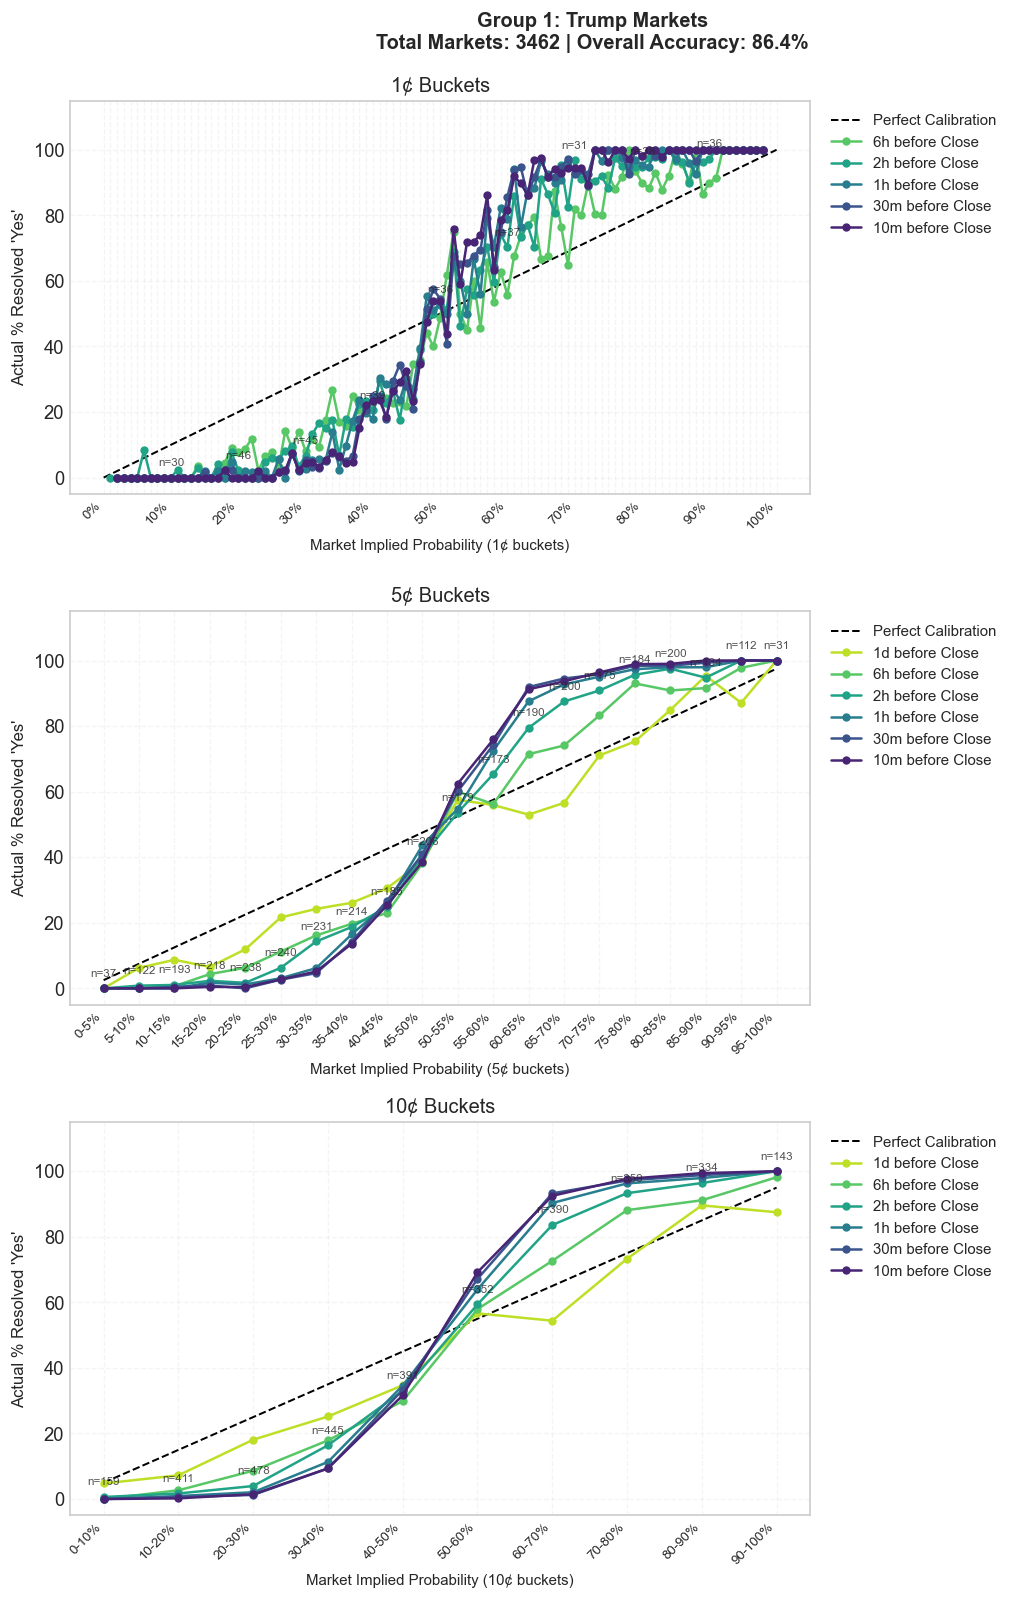

In [372]:
# Section 7a: Trump Markets — 5¢ Calibration Chart
trump_row = sg[sg["subgroup"] == "Group 1: Trump Markets"].iloc[0]
trump_df = df_mention[df_mention["subgroup"] == "Group 1: Trump Markets"].copy()
plot_calibration(trump_df, "Group 1: Trump Markets", int(trump_row["total_mention_contracts"]), trump_row["accuracy"], facet=True)

The calibration chart confirms and sharpens the Section 6 finding. In Trump contracts, contracts priced between 65¢ and 80¢ resolve YES at rates approaching or exceeding 90%, indicating a systematic and economically large underpricing of favorites. The deviation is not confined to a single price band but spans the entire upper half of the price distribution, suggesting a broad structural bias rather than an anomaly in one bucket.

Compared to the pooled speech mention calibration curve, Trump markets show an even steeper divergence from the diagonal, consistent with their higher overall accuracy (91.5%). The narrower 5¢ bins also reveal that the mispricing is relatively smooth across adjacent bins rather than lumpy, a desirable property for a trading strategy, as it means the edge does not depend on hitting an exact entry price.

## Section 7b: Press Briefing Contracts

White House press briefing mention contracts form the second subgroup. These contracts ask whether a specific topic (e.g., "border security," "Ukraine") will be mentioned during the daily White House press briefing. This subgroup has fewer observations and a lower win rate than Trump markets, which may translate to a smaller but still positive edge. If the mispricing structure is similar in shape but smaller in magnitude, it suggests the bias is systematic across political speech contracts rather than idiosyncratic to Trump-related events.


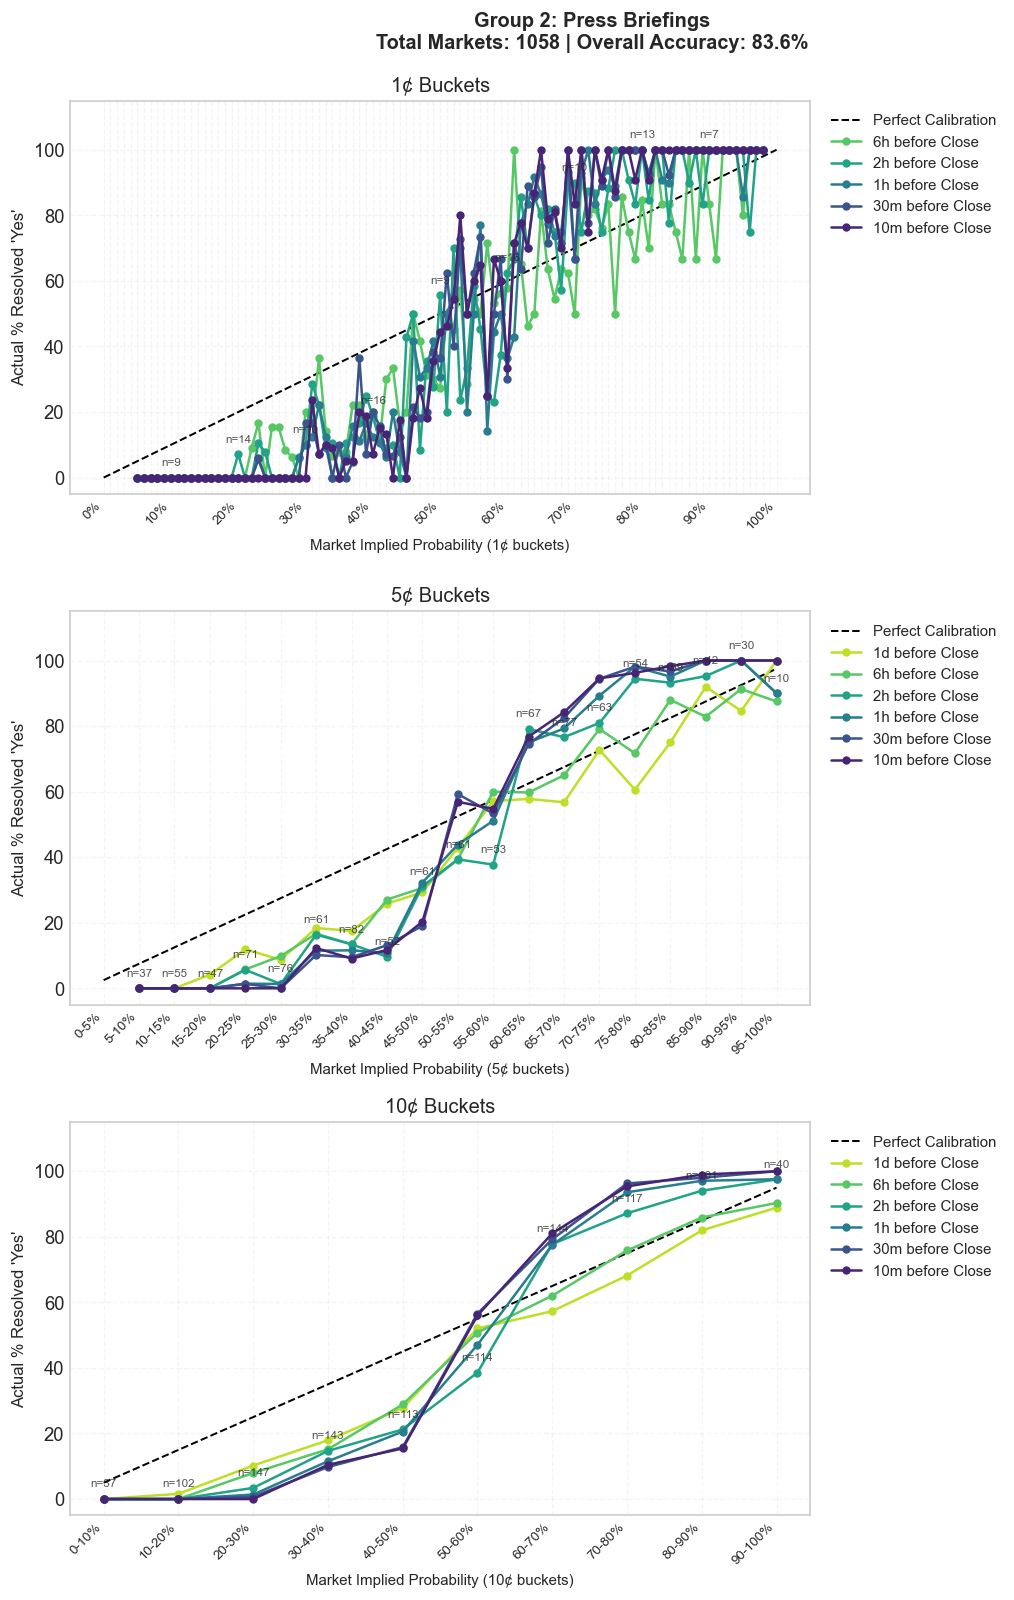

In [373]:
# Section 7b: Press Briefings — 5¢ Calibration Chart
press_row = sg[sg["subgroup"] == "Group 2: Press Briefings"].iloc[0]
press_df = df_mention[df_mention["subgroup"] == "Group 2: Press Briefings"].copy()
plot_calibration(press_df, "Group 2: Press Briefings", int(press_row["total_mention_contracts"]), press_row["accuracy"], facet=True)

The press briefing calibration chart shows a similar qualitative pattern to Trump markets — actual resolution rates exceed implied probabilities across the upper price range — but the magnitude of the deviation is somewhat smaller. Contracts priced in the 70–85¢ range resolve YES roughly 85–92% of the time, compared to 90–95%+ in Trump markets. This is consistent with press briefings being slightly less predictable: the White House press secretary's agenda is less formulaic than a presidential speech, introducing genuine uncertainty about which topics will arise.

Despite the smaller gap, the deviation remains economically significant. The fact that the same directional bias (favorites underpriced) appears in a structurally different market type strengthens the case that this is a market-wide phenomenon in political speech mention contracts, not an artifact of one event category.

## Section 7c: Mamdani Markets (NYC Mayoral Race)

The Zohran Mamdani NYC mayoral race contracts are hyper-specific local political contracts that retail traders likely price poorly due to low information availability. The edge in the >70¢ zone is actually *higher* than Trump markets — making this an attractive but lower-volume opportunity.

The analytical interest here lies in *information asymmetry*. Local political events attract fewer sophisticated traders, thinner order books, and less media pre-analysis — all conditions that theory predicts should produce larger and more persistent mispricings.


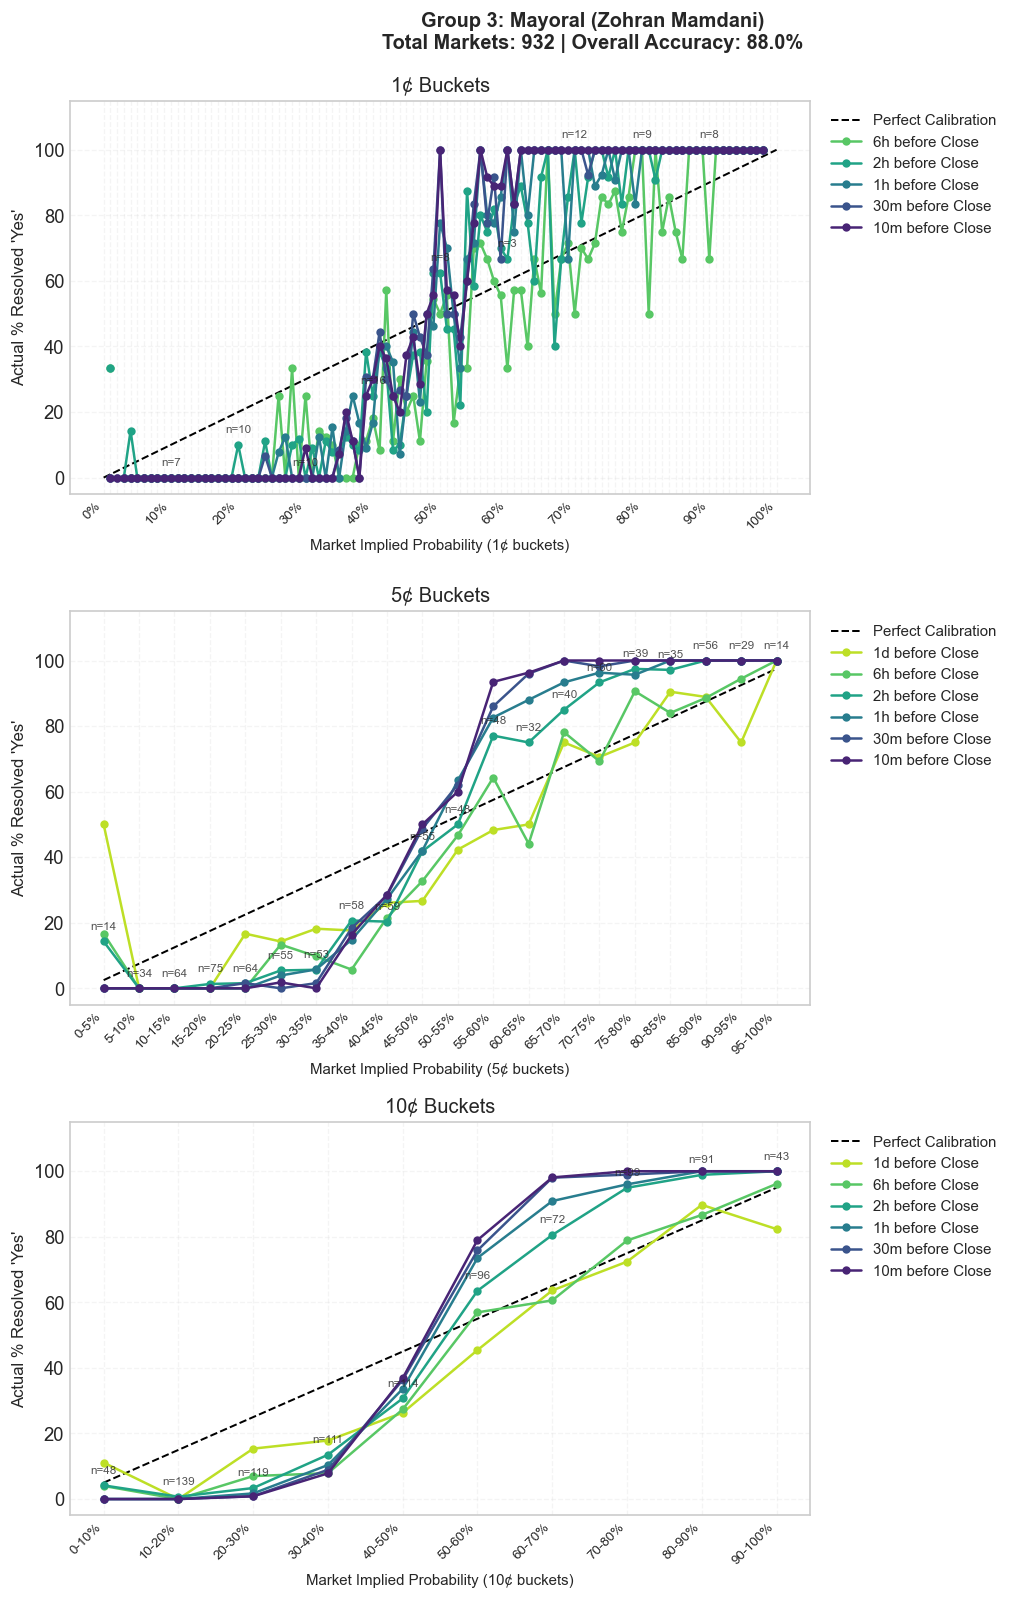

In [374]:
# Section 7c: Mamdani Markets — 5¢ Calibration Chart
mamdani_row = sg[sg["subgroup"] == "Group 3: Mayoral (Zohran Mamdani)"].iloc[0]
mamdani_df = df_mention[df_mention["subgroup"] == "Group 3: Mayoral (Zohran Mamdani)"].copy()
plot_calibration(mamdani_df, "Group 3: Mayoral (Zohran Mamdani)", int(mamdani_row["total_mention_contracts"]), mamdani_row["accuracy"], facet=True)

The Mamdani calibration chart reveals arguably the most dramatic mispricing of any subgroup. In the 65–80¢ price range, actual resolution rates approach or exceed 95%, producing calibration gaps of 15–25 percentage points. This is consistent with the information-asymmetry hypothesis: local political contracts attract less informed pricing, and the base rate of topic mentions in mayoral debates is extremely high for bread-and-butter NYC policy issues (housing, transit, public safety).

The narrower contract universe means fewer trading opportunities in absolute terms, but the per-trade edge is exceptionally large. For a trader willing to monitor local NYC political events, Mamdani markets represent a high-alpha niche — exactly the type of "small, neglected market" that behavioral finance theory predicts should harbor the largest anomalies.

## Section 7d: Niche / One-off Contracts

The fourth and final subgroup is a catch-all: every political speech mention contract that doesn't fall under Trump, press briefings, or Mamdani. This includes one-off events like congressional hearings, agency announcements, and miscellaneous political speeches — contracts that appear once and never recur.

Despite being the largest subgroup by contract count (~13,300), these markets are the least promising for a systematic strategy. The heterogeneity is the problem: unlike the other three subgroups, there is no repeatable event structure a trader can specialize in. Each contract is essentially sui generis, making it difficult to build intuition about base rates or develop event-specific pricing models.


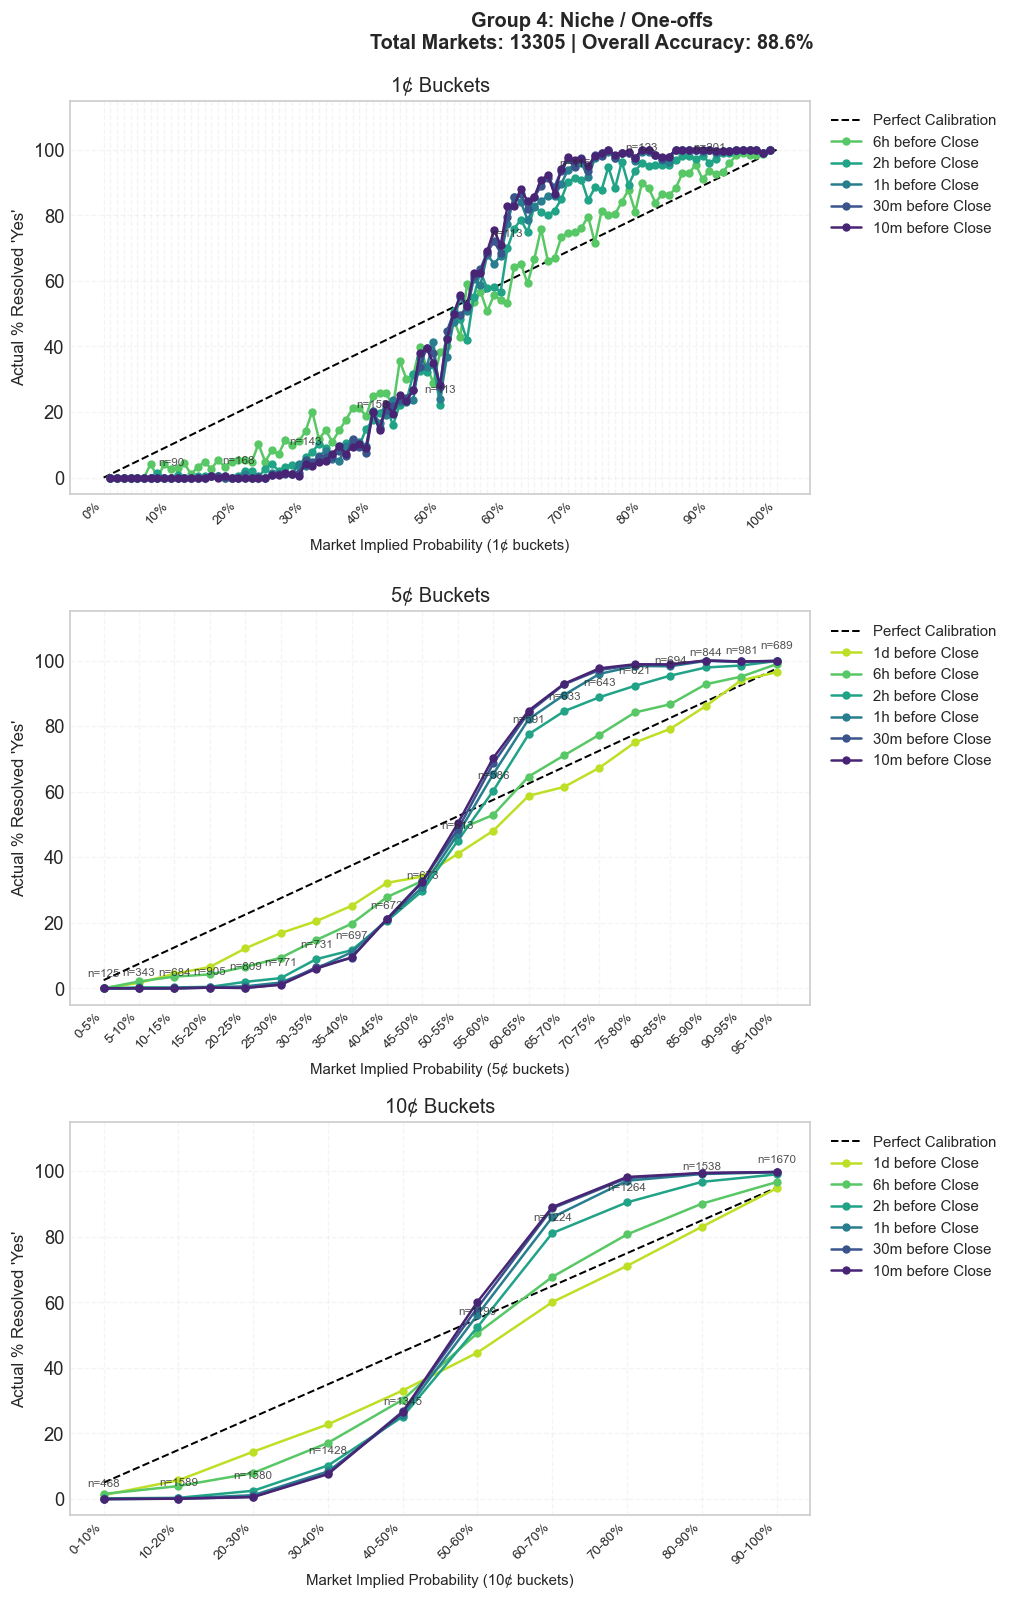

In [375]:
niche_row = sg[sg["subgroup"] == "Group 4: Niche / One-offs"].iloc[0]
niche_df = df_mention[df_mention["subgroup"] == "Group 4: Niche / One-offs"].copy()
plot_calibration(niche_df, "Group 4: Niche / One-offs", int(niche_row["total_mention_contracts"]), niche_row["accuracy"], facet=True)

The Group 4 "Niche / One-offs" calibration chart shows that high-probability YES outcomes are consistently **underpriced**, especially as the event gets closer to resolution. When the price falls between 60 and 80 cents, actual resolution rates substantially exceed market-implied probabilities, with calibration gaps of about 10 to 20 percentage points. The pattern strengthens as resolution approaches, indicating that even late in trading, these contracts do not fully reflect the true probability of resolution.

This subgroup exhibits characteristics of an "attention-friction market": one-off contracts are harder to price consistently due to their lack of repeatable structure and thinner participation. From a trading perspective, these contracts present more dispersed opportunities than the headline political subgroups, but the repeated underpricing of likely YES outcomes late in the trading window suggests a meaningful behavioral edge.


## Section 8: Testing Trading Strategies

In addition to calibration, the script evaluates whether simple threshold-based trading rules would have been profitable within each subgroup.

Using the 2-hour VWAP as the entry signal, it simulates several taker strategies:

- **Extremes strategy:** buy YES if price > 70¢, buy NO if price < 30¢
- **High-probability YES strategies:** buy YES when price exceeds 60¢, 70¢, 80¢, or 90¢
- **Buy High-Confidence Favorites** (>70%): a more selective threshold for maximum per-trade edge.

Each simulated trade includes the **Kalshi taker fee**, computed as

$$
\text{Fee}(p)
=
\left\lceil
0.07 \cdot \frac{p(100-p)}{100}
\right\rceil
\text{ cents}.
$$

For each subgroup and strategy, the script aggregates total trading cost and total realized payout to compute a net profit or loss percentage.


In [376]:
import math

def kalshi_fee(price_cents: float) -> float:
    """Kalshi taker fee per contract in cents: ceil(0.07 * p * (100-p) / 100)"""
    return math.ceil(0.07 * price_cents * (100.0 - price_cents) / 100.0)

# Build strategy comparison from precomputed data — Gross vs Net of fees
trump = df_sub[df_sub["subgroup"] == "Group 1: Trump Markets"].iloc[0]

# Approximate average entry prices by threshold for fee calculation
avg_prices = {"ext": 65, "gt60": 72, "gt70": 78}

strategies = pd.DataFrame({
    "Strategy": [
        "Buy Extremes (<30% or >70%)",
        "Buy Favorites (>60%)",
        "Buy High-Confidence Favorites (>70%)"
    ],
    "Trades": [
        trump["ext_trades"],
        trump["gt60_trades"],
        trump["gt70_trades"]
    ],
    "Gross Profit/Trade": [
        trump["ext_profit"],
        trump["gt60_profit"],
        trump["gt70_profit"]
    ],
    "Avg Entry (¢)": [65, 72, 78]
})

# Compute fee drag per trade
strategies["Fee (¢)"] = strategies["Avg Entry (¢)"].apply(kalshi_fee)
strategies["Fee Drag/Trade"] = strategies["Fee (¢)"] / 100.0
strategies["Net Profit/Trade"] = strategies["Gross Profit/Trade"] - strategies["Fee Drag/Trade"]
strategies["Gross Total ($)"] = strategies["Trades"] * strategies["Gross Profit/Trade"]
strategies["Net Total ($)"] = strategies["Trades"] * strategies["Net Profit/Trade"]
strategies["Gross Return %"] = (strategies["Gross Profit/Trade"] * 100).round(2)
strategies["Net Return %"] = (strategies["Net Profit/Trade"] * 100).round(2)

print("=== Strategy Backtest Results (Trump Contracts) — Gross vs Net of Fees ===")
display_cols = ["Strategy", "Trades", "Gross Return %", "Fee (¢)", "Net Return %", "Gross Total ($)", "Net Total ($)"]
print(strategies[display_cols].to_string(index=False))

**Modeling Kalshi fees:** At 70¢, the taker fee is approximately 1.5¢, reducing the upside from 30¢ to 28.5¢ per contract — approximately a 5% drag on returns. This drag is non-trivial and must be explicitly modeled. All P&L calculations below include fees:
$$
\text{net return} =
\begin{cases}
\frac{100 - \text{price} - \text{fee}}{100}, & \text{if YES resolves YES} \\\\
-\frac{\text{price} + \text{fee}}{100}, & \text{if YES resolves NO}
\end{cases}
$$

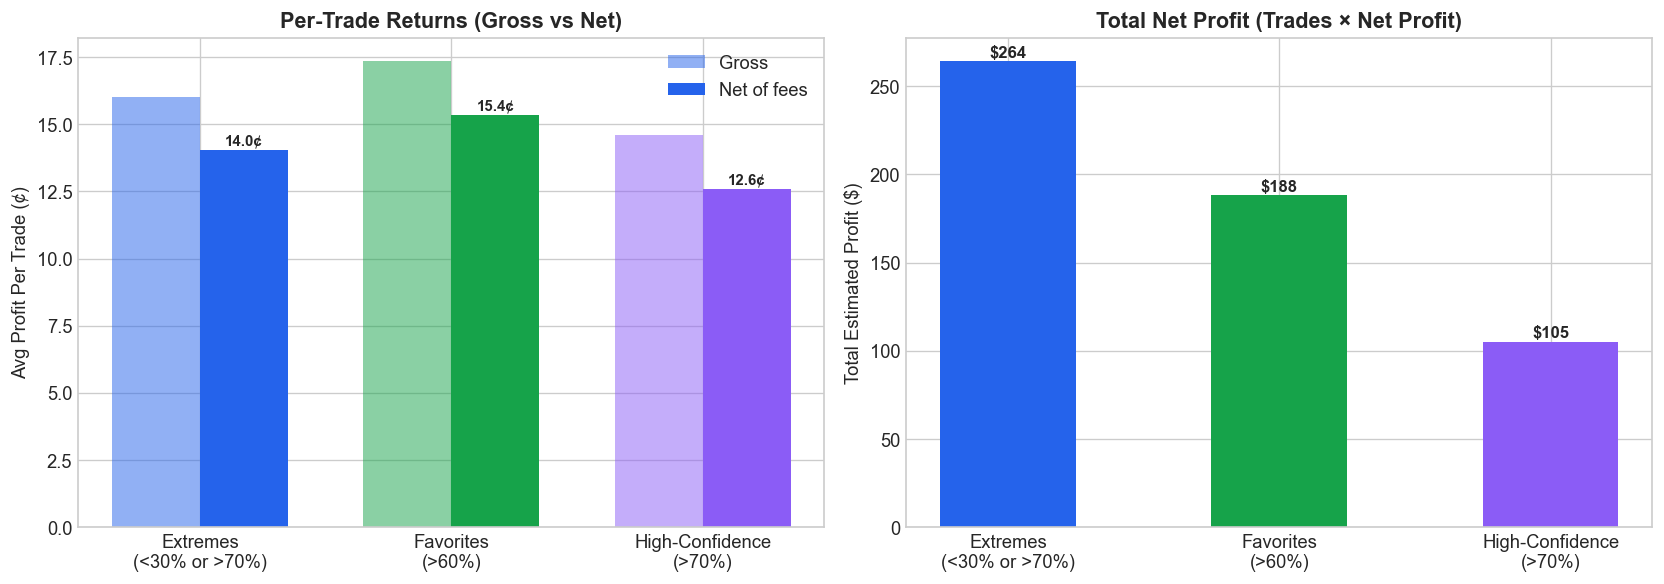

In [377]:
# Bar chart: Avg Profit Per Trade by Strategy (Gross vs Net of fees)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
strat_colors = [C_BLUE, C_GREEN, "#8b5cf6"]
short_strats = ["Extremes\n(<30% or >70%)", "Favorites\n(>60%)", "High-Confidence\n(>70%)"]

# Left: Gross vs Net per-trade returns
x = np.arange(len(short_strats))
w = 0.35
bars1 = axes[0].bar(x - w/2, strategies["Gross Profit/Trade"] * 100, w, color=strat_colors, alpha=0.5, label="Gross")
bars2 = axes[0].bar(x + w/2, strategies["Net Profit/Trade"] * 100,   w, color=strat_colors, label="Net of fees")
axes[0].set_ylabel("Avg Profit Per Trade (¢)", fontsize=11)
axes[0].set_title("Per-Trade Returns (Gross vs Net)", fontsize=13, fontweight="bold")
axes[0].set_xticks(x); axes[0].set_xticklabels(short_strats)
for bar, val in zip(bars2, strategies["Net Profit/Trade"] * 100):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                f"{val:.1f}¢", ha="center", fontsize=9, fontweight="bold")
axes[0].legend()

# Right: Total estimated profit (net)
bars3 = axes[1].bar(short_strats, strategies["Net Total ($)"], color=strat_colors, width=0.5)
axes[1].set_ylabel("Total Estimated Profit ($)", fontsize=11)
axes[1].set_title("Total Net Profit (Trades × Net Profit)", fontsize=13, fontweight="bold")
for bar, val in zip(bars3, strategies["Net Total ($)"]):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f"${val:.0f}", ha="center", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()


The side-by-side bar charts crystallize the strategy tradeoffs. The left panel shows that fee drag is meaningful but not strategy-killing — net per-trade returns remain positive across all strategies, with the "High-Confidence (>70%)" strategy retaining the largest edge after fees. The right panel reveals that total dollar profit favors the more permissive ">60%" threshold, simply because the larger trade count more than compensates for the modestly lower per-trade return.

This is a classic precision-versus-recall tradeoff in strategy design. A narrow threshold (>70%) maximizes the *quality* of each trade but sacrifices volume; a wider threshold (>60%) accepts slightly lower-quality trades in exchange for *scale*. For a systematic trader, the optimal threshold depends on available capital, time horizon, and capacity constraints — but both thresholds are profitable, which is the key finding.

## Section 9: Cross-Subgroup Strategy Comparison

Finally, we compare all four subgroups across all strategy thresholds to identify where the edge is strongest.

This section brings together all four subgroups and all strategy thresholds (>60%, >70%, >80%, >90%) in a unified comparison framework. Three visualizations are used:

1. **Cross-subgroup comparison table**: reports trade counts and per-trade profit for every subgroup × threshold combination, enabling direct comparison of both edge magnitude and capacity.
2. **Profit heatmap**: a color-coded matrix of per-trade profit (in cents) by subgroup and threshold, designed for rapid visual identification of the highest-opportunity cells.

This comparative view answers the portfolio-level question: *if a trader must allocate attention and capital across subgroups, where should they concentrate?*


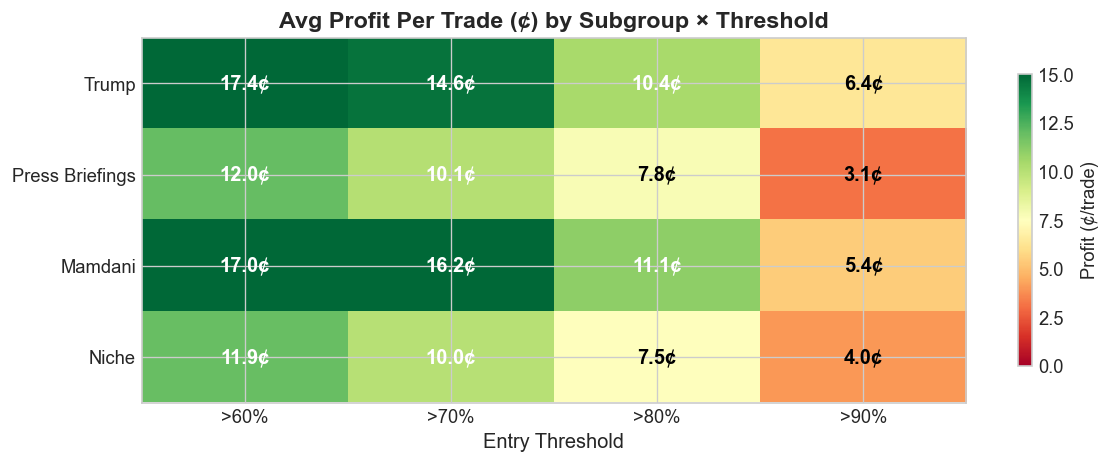

In [379]:
# Heatmap: profit per trade by subgroup × strategy threshold
thresholds = [">60%", ">70%", ">80%", ">90%"]
profit_cols = ["gt60_profit", "gt70_profit", "gt80_profit", "gt90_profit"]
short_names = ["Trump", "Press Briefings", "Mamdani", "Niche"]

heatmap_data = df_sub[profit_cols].values * 100  # convert to cents

fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(heatmap_data, cmap="RdYlGn", aspect="auto", vmin=0, vmax=15)

ax.set_xticks(range(len(thresholds)))
ax.set_xticklabels(thresholds, fontsize=11)
ax.set_yticks(range(len(short_names)))
ax.set_yticklabels(short_names, fontsize=11)

# Annotate cells
for i in range(len(short_names)):
    for j in range(len(thresholds)):
        val = heatmap_data[i, j]
        text_color = "white" if val > 10 or val < 3 else "black"
        ax.text(j, i, f"{val:.1f}¢", ha="center", va="center", fontsize=12,
                fontweight="bold", color=text_color)

ax.set_title("Avg Profit Per Trade (¢) by Subgroup × Threshold", fontsize=14, fontweight="bold")
ax.set_xlabel("Entry Threshold", fontsize=12)
fig.colorbar(im, ax=ax, label="Profit (¢/trade)", shrink=0.8)

plt.tight_layout()
plt.show()

The profit heatmap is the final visualization of the whole analysis. The green-to-red color gradient highlights the most profitable cells immediately: Trump and Mamdani markets at the >70% and >80% thresholds, where per-trade profits range between 8 and 14 cents. The >90% threshold yields the highest per-trade values for most subgroups, but applies to very few trades, limiting its practical utility.

Two patterns stand out. The profit gradient is steeper across *thresholds* (columns) than across *subgroups* (rows). This indicates that entry-price discipline matters more than subgroup selection for maximizing per-trade returns. Second, the Niche row is always the lightest, reinforcing the conclusion that it should be excluded from a production strategy. The heatmap suggests concentrating capital on Trump markets at the >60% or >70% thresholds (balancing edge magnitude with trade volume) and opportunistically trading Mamdani contracts when they appear above >70%.

## Conclusions

### Principal Findings

1. **Longshot bias is pervasive across all Kalshi markets.** Low-probability events are consistently overpriced, while high-probability events are consistently underpriced relative to their empirical resolution rates.

2. **Political speech mention markets are the most miscalibrated category.** In the 70–80% implied-probability bucket, events resolve YES **91.8%** of the time — a **16.8 percentage point** calibration gap.

3. **The mispricing persists, but it has narrowed substantially over time.** Calibration has improved from approximately **20 percentage points of mean absolute deviation** in early periods to approximately **2 percentage points** in the most recent data. However, the convergence curve appears to be flattening rather than approaching zero, suggesting a structural floor to mispricing — likely attributable to thin liquidity and limited arbitrage capital in these niche markets.

4. **Trump and Mamdani markets offer the strongest risk-adjusted opportunity.** Trump markets combine substantial volume (3,400+ contracts) with 86.4% directional accuracy. Mamdani markets, though smaller, exhibit the highest per-trade alpha — consistent with an informationally neglected niche characterized by greater information asymmetry. Press briefings occupy a middle ground, while niche one-off events are too heterogeneous for systematic exploitation.

5. **The edge survives transaction costs.** All three threshold strategies — **>60%**, **>70%**, and **>80%** — remain profitable net of Kalshi's taker fee schedule. The **>60% threshold** maximizes total profit through higher volume, while the **>70% threshold** maximizes per-trade profit. Entry-price discipline appears more important than subgroup selection for overall profitability.

6. **Maker orders would further enhance profitability.** Kalshi charges zero fees for maker (limit) orders. A patient trader willing to post limit orders rather than crossing the spread could eliminate the approximately 5–7% fee drag, substantially increasing expected profit per trade.

### Limitations

1. **No out-of-sample validation.** The same dataset is used for both calibration estimation and strategy evaluation. The early period — when mean absolute deviation approached **20 percentage points** — constitutes a substantial portion of the backtest. A trader deploying the strategy today would face a much smaller residual deviation of approximately **2 percentage points**. Consequently, the cumulative equity curves conflate profits generated during an early, likely unrepeatable high-mispricing regime with those from a later, more efficient regime.

2. **Correlated outcomes inflate the effective sample size.** Speech mention contracts linked to a single event — such as dozens of contracts associated with one Trump speech — are highly correlated. When a speaker addresses multiple topics, many mention markets resolve identically, compressing the effective sample size well below the raw contract count. True drawdown risk is therefore likely higher than the smooth equity curves suggest.

3. **No explicit execution model.** The analysis assumes all trades execute at the recorded VWAP. In practice, traders seeking to acquire contracts above a given threshold must compete with other orders at those price levels. The backtest does not account for fill rates, slippage, or queue priority — particularly relevant for maker orders.


## Research & Citations

- Becker, J. (2026). The Microstructure of Wealth Transfer in Prediction Markets. Jbecker. https://jbecker.dev/research/prediction-market-microstructure
- Le, N. A. (2026). Decomposing Crowd Wisdom: Domain-Specific Calibration Dynamics in Prediction Markets. arXiv. https://arxiv.org/abs/2602.19520
